# Warm-up data exploration and visualization

<style>
.MathJax {
  font-family: "Common HTML";
}
</style>

$$
\newcommand{\eg}{{\it e.g.}}
\newcommand{\ie}{{\it i.e.}}
\newcommand{\argmin}{\operatornamewithlimits{argmin}}
\newcommand{\mc}{\mathcal}
\newcommand{\mb}{\mathbb}
\newcommand{\mf}{\mathbf}
\newcommand{\minimize}{{\text{minimize}}}
\newcommand{\diag}{{\text{diag}}}
\newcommand{\cond}{{\text{cond}}}
\newcommand{\rank}{{\text{rank }}}
\newcommand{\range}{{\mathcal{R}}}
\newcommand{\null}{{\mathcal{N}}}
\newcommand{\tr}{{\text{trace}}}
\newcommand{\dom}{{\text{dom}}}
\newcommand{\dist}{{\text{dist}}}
\newcommand{\R}{\mathbf{R}}
\newcommand{\SM}{\mathbf{S}}
\newcommand{\ball}{\mathcal{B}}
\newcommand{\bmat}[1]{\begin{bmatrix}#1\end{bmatrix}}
\newcommand{\loss}{\ell}
\newcommand{\eloss}{\mc{L}}
\newcommand{\abs}[1]{| #1 |}
\newcommand{\norm}[1]{\| #1 \|}
\newcommand{\tp}{T}
$$

__<div style="text-align: right"> ASE3001: Computational Experiments for Aerospace Engineering, Inha University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@inha.ac.kr) </div>_



___
__Note__

- _This assignment description was prepared with the assistance of ChatGPT 5._

- _Students are also permitted to use ChatGPT to support their work on this assignment, provided that all sources of assistance are properly acknowledged, and that the correctness of ChatGPT’s responses is carefully verified before use._

<br>

___

<br>

## Objective

The purpose of this assignment is to provide students with an opportunity to practice essential Python-based data analysis and visualization skills. Building upon the introductory lecture on Python, NumPy, Matplotlib, and Pandas, this task emphasizes independent exploration of aerospace-related datasets and the extraction of meaningful insights.



## Task Description

Each student is required to search for a dataset of personal interest related to aerospace science or engineering. The dataset may be obtained from publicly available online sources, such as governmental agencies, research organizations, or academic repositories. Once an appropriate dataset has been identified, students should perform the following steps:

-	Provide a brief explanation of why this dataset was selected, highlighting its relevance or personal interest in the aerospace domain.
-	Import the dataset into Python using Pandas (e.g., from CSV or Excel format).
-	Preprocess the data as necessary (e.g., handling missing values, renaming columns, adjusting units).
-	Apply NumPy operations, where appropriate, to manipulate or transform the data.
-	Visualize the results using Matplotlib, ensuring that the plots are clear, properly labeled, and scientifically informative.



## Deliverables

All work must be completed directly in the provided Jupyter Notebook file, and the students should write both the code cells (for data handling, processing, and visualization) and the report sections (in Markdown cells) within the same notebook.

The written report should immediately follow the assignment description in the notebook and include the following elements:

-	A description of the dataset, including its source, relevance to aerospace applications, and the motivation for selecting it.
- A clear explanation of the preprocessing steps and analysis methods applied.
- Graphical results (plots, charts, or other visualizations) generated from the dataset.
- A discussion of insights gained from the analysis and potential implications in the aerospace domain.


<br>

---

<br>


https://data.nasa.gov/dataset/deorbit-descent-and-landing-flight-1-ddl-f1#:~:text=%2A%20%20DDL

This project analyzes the NASA Deorbit, Descent, and Landing (DDL-F1) flight dataset, which provides detailed measurements of a vehicle’s flight dynamics and onboard sensors. The primary objective is to apply numerical integration to the raw IMU(Inertial Measurement Unit) measurements in order to estimate the vehicle’s velocity over time. Then, the estimated velocity is compared with the provided ground-truth data through interpolation for precise temporal alignment. This process allows us to visualize and quantify the cumulative integration error, commonly referred to as drift, which is a limitation of inertial navigation systems.

The following Python script demonstrates this approach by loading the dataset, performing numerical integration of the IMU data, and comparing the results with the ground-truth measurements to evaluate the effect of sensor drift.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

'''
truth = pd.read_csv(r'/content/drive/MyDrive/Computation Lab/truth.csv')
dlc = pd.read_csv(r'/content/drive/MyDrive/Computation Lab/dlc.csv')
lidar = pd.read_csv(r'/content/drive/MyDrive/Computation Lab/commercial_lidar.csv')
'''

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

truth = pd.read_csv(r'C:\Users\변정우\OneDrive\Desktop\3학년\수치해석 프로젝트\1주차 과제\Flight1_Catered_Dataset-20201013\Data\truth.csv')
dlc = pd.read_csv(r'C:\Users\변정우\OneDrive\Desktop\3학년\수치해석 프로젝트\1주차 과제\Flight1_Catered_Dataset-20201013\Data\dlc.csv')
lidar = pd.read_csv(r'C:\Users\변정우\OneDrive\Desktop\3학년\수치해석 프로젝트\1주차 과제\Flight1_Catered_Dataset-20201013\Data\commercial_lidar.csv')

# 1. 데이터 전처리
# 컬럼 이름에 포함되는 불필요한 공백을 제거
truth.columns = truth.columns.str.strip()
dlc.columns = dlc.columns.str.strip()
lidar.columns = lidar.columns.str.strip()

# TIME_NANOSECONDS_TAI 컬럼을 이용해서 시작점 기준 상대 시간 계산
start_time = truth['TIME_NANOSECONDS_TAI'].iloc[0]
truth['Time_s'] = (truth['TIME_NANOSECONDS_TAI'] - start_time) / 1e9
dlc['Time_s'] = (dlc['TIME_NANOSECONDS_TAI'] - start_time) / 1e9
lidar['Time_s'] = (lidar['TIME_NANOSECONDS_TAI'] - start_time) / 1e9

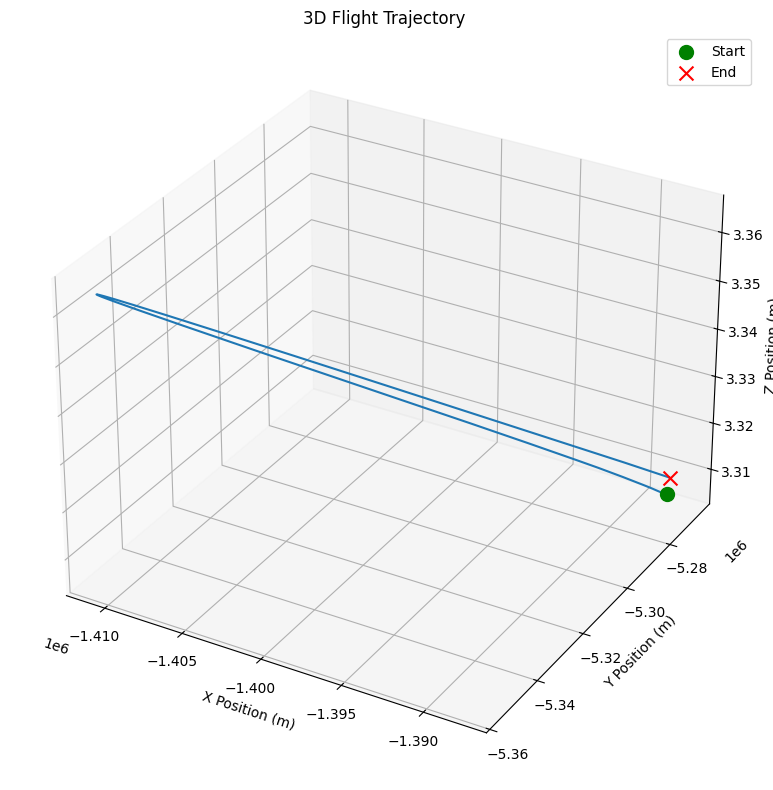

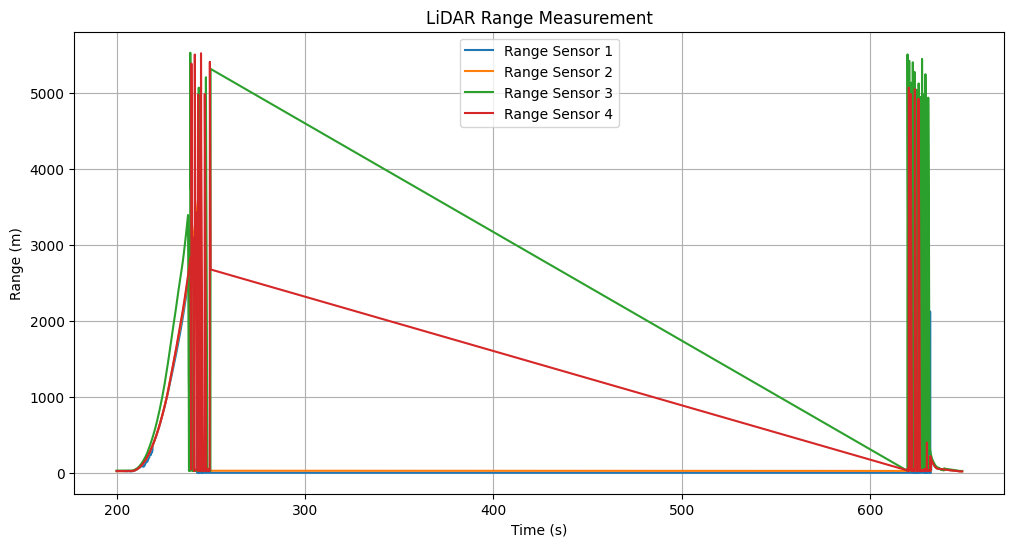

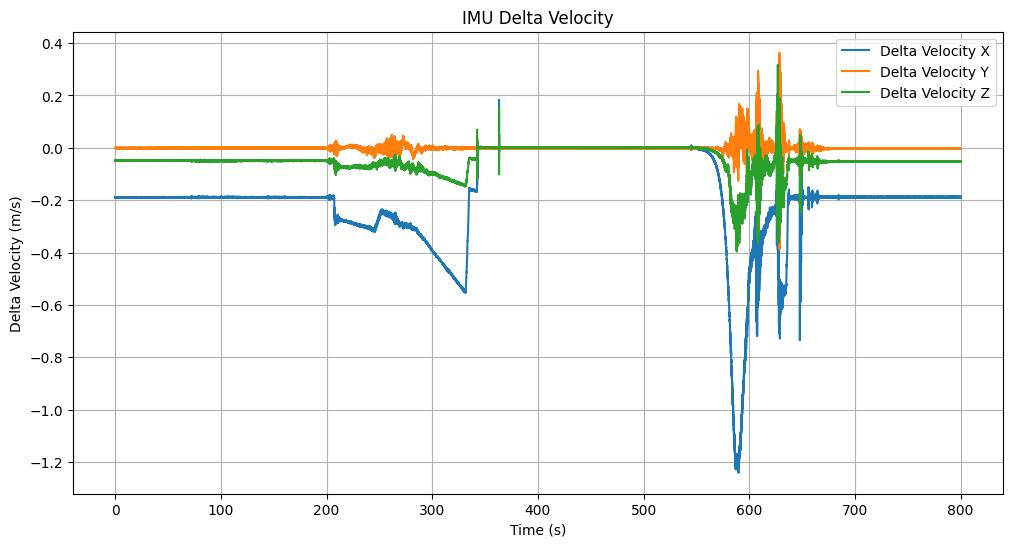

In [3]:
# 2. 데이터 시각화 및 분석
# 2-1. 비행 궤적 3D 시각화 (truth.csv)
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
# 3D 궤적
ax.plot(truth['truth_pos_CON_ECEF_ECEF_M[1]'],
        truth['truth_pos_CON_ECEF_ECEF_M[2]'],
        truth['truth_pos_CON_ECEF_ECEF_M[3]'])
# 시작점, 끝점 표시
ax.scatter(truth['truth_pos_CON_ECEF_ECEF_M[1]'].iloc[0],
        truth['truth_pos_CON_ECEF_ECEF_M[2]'].iloc[0],
        truth['truth_pos_CON_ECEF_ECEF_M[3]'].iloc[0],
        color='green', marker='o', s=100, label='Start')
ax.scatter(truth['truth_pos_CON_ECEF_ECEF_M[1]'].iloc[-1],
        truth['truth_pos_CON_ECEF_ECEF_M[2]'].iloc[-1],
        truth['truth_pos_CON_ECEF_ECEF_M[3]'].iloc[-1],
        color='red', marker='x', s=100, label='End')
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Z Position (m)')
ax.set_title('3D Flight Trajectory')
ax.legend()
plt.tight_layout()
plt.show()

# 2-2. LiDAR 센서 데이터 시각화 (commercial_lidar.csv)
plt.figure(figsize=(12, 6))
plt.plot(lidar['Time_s'], lidar['OMPS_Range_M[1]'], label='Range Sensor 1')
plt.plot(lidar['Time_s'], lidar['OMPS_Range_M[2]'], label='Range Sensor 2')
plt.plot(lidar['Time_s'], lidar['OMPS_Range_M[3]'], label='Range Sensor 3')
plt.plot(lidar['Time_s'], lidar['OMPS_Range_M[4]'], label='Range Sensor 4')
plt.xlabel('Time (s)')
plt.ylabel('Range (m)')
plt.title('LiDAR Range Measurement')
plt.legend()
plt.grid(True)
plt.show()

# 2-3. IMU 센서 데이터 시각화 (dlc.csv)
plt.figure(figsize=(12, 6))
plt.plot(dlc['Time_s'], dlc['DATA_DELTA_VEL[1]'], label='Delta Velocity X')
plt.plot(dlc['Time_s'], dlc['DATA_DELTA_VEL[2]'], label='Delta Velocity Y')
plt.plot(dlc['Time_s'], dlc['DATA_DELTA_VEL[3]'], label='Delta Velocity Z')
plt.xlabel('Time (s)')
plt.ylabel('Delta Velocity (m/s)')
plt.title('IMU Delta Velocity')
plt.legend()
plt.grid(True)
plt.show()


This analysis reveals a significant difference between the ground truth and the estimated trajectory from the IMU sensor. While the initial states are nearly aligned, the IMU's estimated velocity and position show cumulative errors over time, known as sensor drift, which lead to a substantial final position error. Therefore, it is important to use external aiding sources such as LiDAR or GPS to correct these cumulative errors in real-world inertial navigation systems.

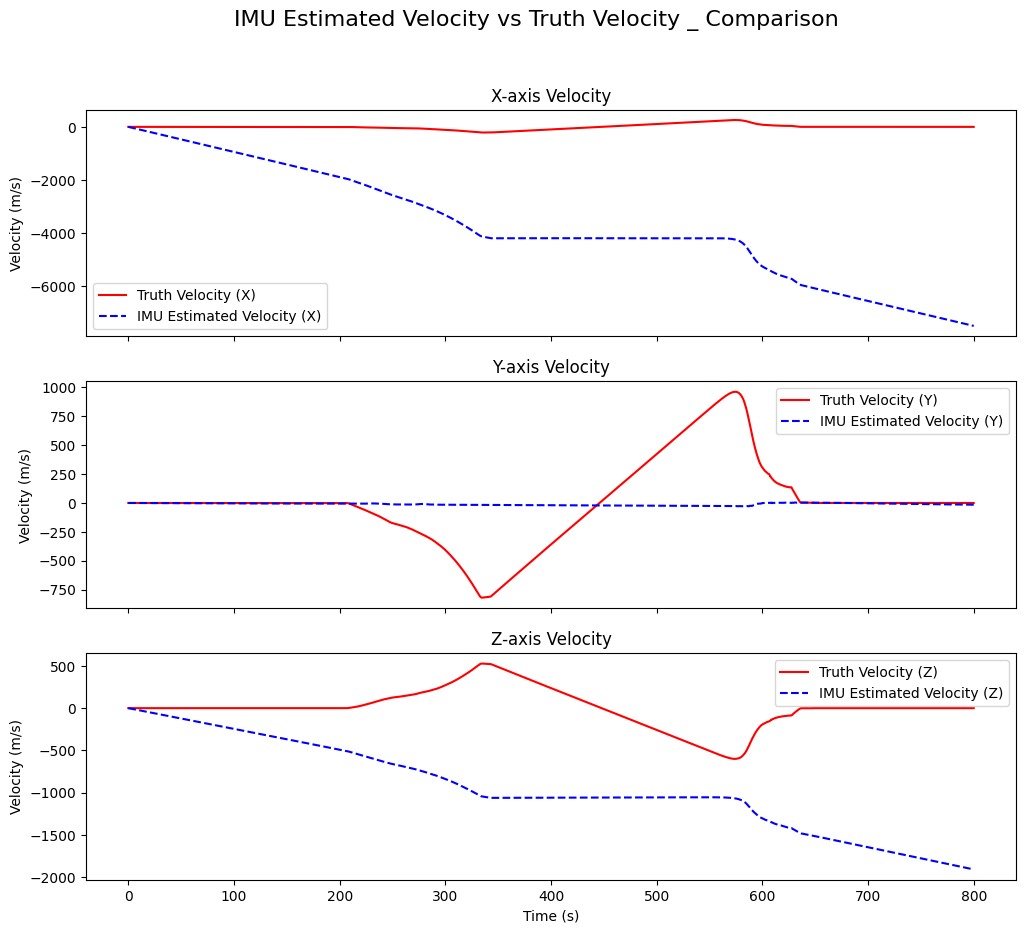

In [4]:
# 3. estimated velocity VS truth velocity
# 3-1. 초기 속도 설정
initial_V = truth[['truth_vel_CON_ECEF_ECEF_MpS[1]',
                'truth_vel_CON_ECEF_ECEF_MpS[2]',
                'truth_vel_CON_ECEF_ECEF_MpS[3]']].iloc[0].values

# 3-2. Delta Velocity을 누적 합산하여 속도 계산
delta_V = dlc[['DATA_DELTA_VEL[1]', 'DATA_DELTA_VEL[2]', 'DATA_DELTA_VEL[3]']].values
total_V = np.vstack([initial_V, delta_V])
estimated_V = np.cumsum(total_V, axis=0)[:-1]

# 3-3. 계산된 속도를 dlc에 새로운 컬럼으로 추가
dlc[['vel_x_imu', 'vel_y_imu', 'vel_z_imu']] = estimated_V

# 4. 실제 속도와 IMU 추정 속도 비교 시각화
# 4-1. dlc 데이터 길이 조정을 위한 truth 데이터 resampling
# truth 데이터가 dlc 데이터보다 2배 많으므로, 2칸 간격으로 설정해야 조정 가능
resampled_truth = truth.iloc[::2, :].reset_index(drop=True)

# 4-2. 그래프 그리기
fig,axes=plt.subplots(3,1,figsize=(12,10),sharex=True)
fig.suptitle('IMU Estimated Velocity vs Truth Velocity _ Comparison', fontsize=16)

# X축 속도 비교
axes[0].plot(resampled_truth['Time_s'], resampled_truth['truth_vel_CON_ECEF_ECEF_MpS[1]'], 'r-', label='Truth Velocity (X)')
axes[0].plot(dlc['Time_s'], dlc['vel_x_imu'], 'b--', label='IMU Estimated Velocity (X)')
axes[0].set_ylabel('Velocity (m/s)')
axes[0].legend()
axes[0].set_title('X-axis Velocity')

# Y축 속도 비교
axes[1].plot(resampled_truth['Time_s'], resampled_truth['truth_vel_CON_ECEF_ECEF_MpS[2]'], 'r-', label='Truth Velocity (Y)')
axes[1].plot(dlc['Time_s'], dlc['vel_y_imu'], 'b--', label='IMU Estimated Velocity (Y)')
axes[1].set_ylabel('Velocity (m/s)')
axes[1].legend()
axes[1].set_title('Y-axis Velocity')

# Z축 속도 비교
axes[2].plot(resampled_truth['Time_s'], resampled_truth['truth_vel_CON_ECEF_ECEF_MpS[3]'], 'r-', label='Truth Velocity (Z)')
axes[2].plot(dlc['Time_s'], dlc['vel_z_imu'], 'b--', label='IMU Estimated Velocity (Z)')
axes[2].set_ylabel('Velocity (m/s)')
axes[2].set_xlabel('Time (s)')
axes[2].legend()
axes[2].set_title('Z-axis Velocity')

plt.show()

This graph visualizes the performance degradation of the IMU's estimated velocity compared with the ground truth directly. While the estimation(blue line) closely matches the actual velocity(red line) at the beginning (especially y-axis), the gap between the two lines increasingly widens over time. It means that the integration of IMU measurements leads to cumulative errors, similar to the result above.

In [7]:
# 5. NumPy 배열로 변환 및 초기값 설정 (Position, Velocity, Time)
truth_P = truth[['truth_pos_CON_ECEF_ECEF_M[1]', 'truth_pos_CON_ECEF_ECEF_M[2]', 'truth_pos_CON_ECEF_ECEF_M[3]']].values
truth_V = truth[['truth_vel_CON_ECEF_ECEF_MpS[1]', 'truth_vel_CON_ECEF_ECEF_MpS[2]', 'truth_vel_CON_ECEF_ECEF_MpS[3]']].values
dlc_delta_V = dlc[['DATA_DELTA_VEL[1]', 'DATA_DELTA_VEL[2]', 'DATA_DELTA_VEL[3]']].values

dlc_T, truth_T = dlc['Time_s'].values, truth['Time_s'].values
initial_P, initial_V = truth_P[0], truth_V[0]

# 6. 수치 적분을 이용한 속도 및 위치 추정 (오일러 방법)
# 6-1. 속도 추정
Estimated_V = np.cumsum(np.vstack([initial_V, dlc_delta_V]), axis=0)[:-1]

# 6-2. 위치 추정
# 각 스텝의 시간 간격(dt), 위치 변화량, 최종 위치
dt = np.diff(dlc_T, prepend=0)
delta_P = Estimated_V * dt[:, np.newaxis]
Estimated_P = np.cumsum(np.vstack([initial_P, delta_P]), axis=0)[:-1]

# 7. 오차 분석을 위한 데이터 정렬 (보간법)
# truth data를 dlc의 Tline에 맞춰 보간
interp_pos_x = np.interp(dlc_T, truth_T, truth_P[:, 0])
interp_pos_y = np.interp(dlc_T, truth_T, truth_P[:, 1])
interp_pos_z = np.interp(dlc_T, truth_T, truth_P[:, 2])
truth_pos_interp = np.vstack([interp_pos_x, interp_pos_y, interp_pos_z]).T

# 8. 수치 결과 출력
# 8-1. 최종 위치 비교
final_truth_P = truth_pos_interp[-1]
final_Estimated_P = Estimated_P[-1]
error_P = final_Estimated_P - final_truth_P
total_error_P = np.linalg.norm(error_P)
print('1. 최종 위치 분석')
print(f' - 실제 최종 위치 (X, Y, Z): ({final_truth_P[0]:.3f}, {final_truth_P[1]:.3f}, {final_truth_P[2]:.3f}) m')
print(f' - IMU 추정 최종 위치 (X, Y, Z): ({final_Estimated_P[0]:.3f}, {final_Estimated_P[1]:.3f}, {final_Estimated_P[2]:.3f}) m')
print(f' - 최종 도착 지점 오차 (3D 거리): {total_error_P:.3f} m')

# 8-2. 위치 오차 통계
P_error = Estimated_P - truth_pos_interp
P_RMSE = np.sqrt(np.mean(P_error**2, axis=0))
P_error_max = np.max(np.abs(P_error), axis=0)
print('\n2. 위치 오차 통계')
print(f' - RMSE (X, Y, Z): ({P_RMSE[0]:.3f}, {P_RMSE[1]:.3f}, {P_RMSE[2]:.3f}) m')
print(f' - 최대 절대 오차 (X, Y, Z): ({P_error_max[0]:.3f}, {P_error_max[1]:.3f}, {P_error_max[2]:.3f}) m')

1. 최종 위치 분석
 - 실제 최종 위치 (X, Y, Z): (-1387989.681, -5267172.398, 3309312.462) m
 - IMU 추정 최종 위치 (X, Y, Z): (-4395088.804, -5277526.949, 2548157.394) m
 - 최종 도착 지점 오차 (3D 거리): 3101952.512 m

2. 위치 오차 통계
 - RMSE (X, Y, Z): (1361543.401, 36318.243, 358583.521) m
 - 최대 절대 오차 (X, Y, Z): (3007099.123, 81756.882, 761155.068) m


By numerically integrating the IMU's Δv with the Euler method, it is possible to estimate the velocity and position. For an intuitive comparison, the ground truth data was interpolated onto the same timeline, allowing for a numerical analysis of the results. The position error statistics reveal the overall magnitude of the sensor drift, which was largest on the X and Z axes and relatively smaller on the Y-axis. Since timing misalignment is probably negligible, the divergence arises from the process of applying integration physics.

Ultimately, both the visual and numerical results demonstrate the need for external aiding sensors to ensure accurate state estimation. Based on research to solve this problem, it was found that the IMU's cumulative error can be resolved by applying a sensor fusion algorithm, such as the Kalman Filter. This method corrects real-time errors by using the precise measurements of a LiDAR sensor. Therefore, if the Kalman filter algorithm was applied to the data, the result can be expected to obtain position and velocity estimation results with much higher precision.

*Reference
: L. von Stumberg, V. Usenko, and D. Cremers, "Tightly-coupled Lidar-inertial Odometry and Mapping," 2018.